# Compare Global Air Quality Sensor Networks in Python

**Goal:** Compare data quality, coverage, and measurement distributions across
three low-cost sensor networks (PurpleAir, Sensor.Community, AirQo) —
a workflow for a review paper on citizen science air quality monitoring.

**API keys required:** `PURPLEAIR_API_KEY`, `AIRQO_API_KEY`
(Sensor.Community requires no key)

**Aeolus features demonstrated:**
- `list_sources()` and `get_source_info()` for programmatic discovery
- Multi-source metadata comparison
- `download()` with dict format across 3 networks
- Schema consistency across low-cost sensor sources
- Ratification/QA flag comparison
- `viz.plot_distribution()` for cross-network distributions

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

# Check required API keys
required = {
    "PURPLEAIR_API_KEY": "PurpleAir",
    "AIRQO_API_KEY": "AirQo",
}
missing = {src: key for key, src in required.items() if not os.environ.get(key)}
if missing:
    raise EnvironmentError(
        f"Missing API keys: {list(missing.values())}\n"
        f"Add them to your .env file. See .env.example for details."
    )

In [2]:
import aeolus
from aeolus import metrics, viz
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

## 1. Network Discovery

Start by programmatically listing available sources and their capabilities.
This is how an LLM agent or automated pipeline would discover Aeolus.

In [3]:
# List all primary sources
sources = aeolus.list_sources()
print(f"Available sources: {sources}")

# Get info for our three low-cost sensor networks
lcs_networks = ["PURPLEAIR", "SENSOR_COMMUNITY", "AIRQO"]

for name in lcs_networks:
    info = aeolus.get_source_info(name)
    print(f"\n{name}:")
    print(f"  Type: {info.get('type', 'unknown')}")
    print(f"  Requires API key: {'yes' if info.get('requires_key') else 'no'}")

Available sources: ['AIRNOW', 'AIRQO', 'AQE', 'AURN', 'BREATHE_LONDON', 'EEA', 'LAQN', 'NI', 'OPENAQ', 'PURPLEAIR', 'SAQN', 'SENSOR_COMMUNITY', 'SONITUS', 'WAQN']

PURPLEAIR:
  Type: portal
  Requires API key: no

SENSOR_COMMUNITY:
  Type: network
  Requires API key: no

AIRQO:
  Type: network
  Requires API key: no


## 2. Metadata Comparison

Fetch metadata from all three networks and compare coverage.
All return the standard metadata schema: `site_code`, `site_name`,
`latitude`, `longitude`, `source_network`.

In [4]:
# Fetch metadata — approach varies by network type
# AirQo is a network (discrete list)
airqo_meta = aeolus.networks.get_metadata("AIRQO")

# PurpleAir is a portal (search required)
# Search in a shared bounding box (London area for co-location)
london_bbox = (-0.5, 51.3, 0.3, 51.7)  # (min_lon, min_lat, max_lon, max_lat)

pa_meta = aeolus.portals.find_sites("PURPLEAIR", bbox=london_bbox)

# Sensor.Community is a network — use top-level find_sites()
sc_meta = aeolus.find_sites("SENSOR_COMMUNITY", bbox=london_bbox)

# Ensure site_name column exists (some sources may not return it)
for meta in [pa_meta, sc_meta, airqo_meta]:
    if "site_name" not in meta.columns:
        meta["site_name"] = meta["site_code"]

print(f"Sensors in London area:")
print(f"  PurpleAir:        {len(pa_meta)}")
print(f"  Sensor.Community: {len(sc_meta)}")
print(f"  AirQo (global):   {len(airqo_meta)}")


Sensors in London area:
  PurpleAir:        16
  Sensor.Community: 53
  AirQo (global):   531


In [5]:
# All three return the same core columns — verify schema consistency
core_cols = ["site_code", "site_name", "latitude", "longitude", "source_network"]

for name, meta in [("PurpleAir", pa_meta), ("Sensor.Community", sc_meta), ("AirQo", airqo_meta)]:
    has_core = all(c in meta.columns for c in core_cols)
    extra = [c for c in meta.columns if c not in core_cols]
    print(f"{name}: core schema \u2705" if has_core else f"{name}: core schema \u274c")
    if extra:
        print(f"  Extra columns: {extra[:5]}{'...' if len(extra) > 5 else ''}")

PurpleAir: core schema ✅
  Extra columns: ['sensor_index', 'date_created', 'last_seen', 'private', 'name']...
Sensor.Community: core schema ✅
  Extra columns: ['measurands', 'sensor_type', 'location_type', 'country']
AirQo: core schema ✅
  Extra columns: ['generated_name', 'formatted_name', 'approximate_latitude', 'approximate_longitude', 'country']...


## 3. Download Comparable Data

Select a few sensors from each network and download the same time period.
The standard 8-column data schema makes cross-network comparison seamless.

In [6]:
# Pick sensors from each network
pa_sites = pa_meta["site_code"].head(2).tolist()
sc_sites = sc_meta["site_code"].head(2).tolist()
airqo_sites = airqo_meta["site_code"].head(2).tolist()

print(f"PurpleAir sites: {pa_sites}")
print(f"Sensor.Community sites: {sc_sites}")
print(f"AirQo sites: {airqo_sites}")

PurpleAir sites: ['263101', '5816']
Sensor.Community sites: ['72230', '72229']
AirQo sites: ['69419f4609357b00130ab4f7', '6941a183fe657a0013b41793']


In [7]:
# Download 3 days from all three networks in one call
start = datetime(2024, 7, 1)
end = datetime(2024, 7, 3)

all_data = aeolus.download(
    {
        "PURPLEAIR": pa_sites,
        "SENSOR_COMMUNITY": sc_sites,
        "AIRQO": airqo_sites,
    },
    start_date=start,
    end_date=end,
)

print(f"Total records: {len(all_data):,}")
print(f"\nRecords by source:")
print(all_data.groupby("source_network").size())
print(f"\nSchema: {all_data.columns.tolist()}")

/Users/ruaraidhdobson/Dropbox/Personal/sls/aeolus/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total records: 240

Records by source:
source_network
PURPLEAIR    240
dtype: int64

Schema: ['site_code', 'date_time', 'measurand', 'value', 'units', 'source_network', 'ratification', 'created_at']


## 4. Data Quality Comparison

Compare ratification flags, data capture, and reporting frequency
across networks.

In [8]:
# Ratification flags by network
print("Ratification flags by network:")
print("="*50)
for network in all_data["source_network"].unique():
    net_data = all_data[all_data["source_network"] == network]
    flags = net_data["ratification"].value_counts()
    print(f"\n{network}:")
    for flag, count in flags.items():
        print(f"  {flag}: {count:,}")

Ratification flags by network:

PURPLEAIR:
  Validated: 144
  Single Channel (A): 96


In [9]:
# Data capture assessment per network
pm25 = all_data[all_data["measurand"] == "PM2.5"]

daily = metrics.time_average(pm25, freq="D")
daily_pm = daily[daily["measurand"] == "PM2.5"]

capture_by_network = (
    daily_pm
    .groupby("source_network")["data_capture"]
    .agg(["mean", "min", "max"])
    .round(2)
)

print("Daily data capture by network:")
capture_by_network

Daily data capture by network:


,mean,min,max
source_network,,,
PURPLEAIR,0.67,0.04,1.0


## 5. Measurement Distribution Comparison

Compare PM\u2082.\u2085 distributions across networks. Differences may reflect
genuine spatial variation, sensor technology, or calibration approaches.

In [10]:
# Summary statistics by network
summary = (
    pm25
    .groupby("source_network")["value"]
    .describe()
    .round(1)
)

print("PM\u2082.\u2085 Summary Statistics by Network (\u00b5g/m\u00b3):")
summary

PM₂.₅ Summary Statistics by Network (µg/m³):


,count,mean,std,min,25%,50%,75%,max
source_network,,,,,,,,
PURPLEAIR,48.0,3.0,1.2,0.6,2.2,2.8,3.7,5.4


/var/folders/vv/gm__lp517938mzyh97_4gc2w0000gn/T/ipykernel_65094/102200687.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_network, labels=networks, patch_artist=True)


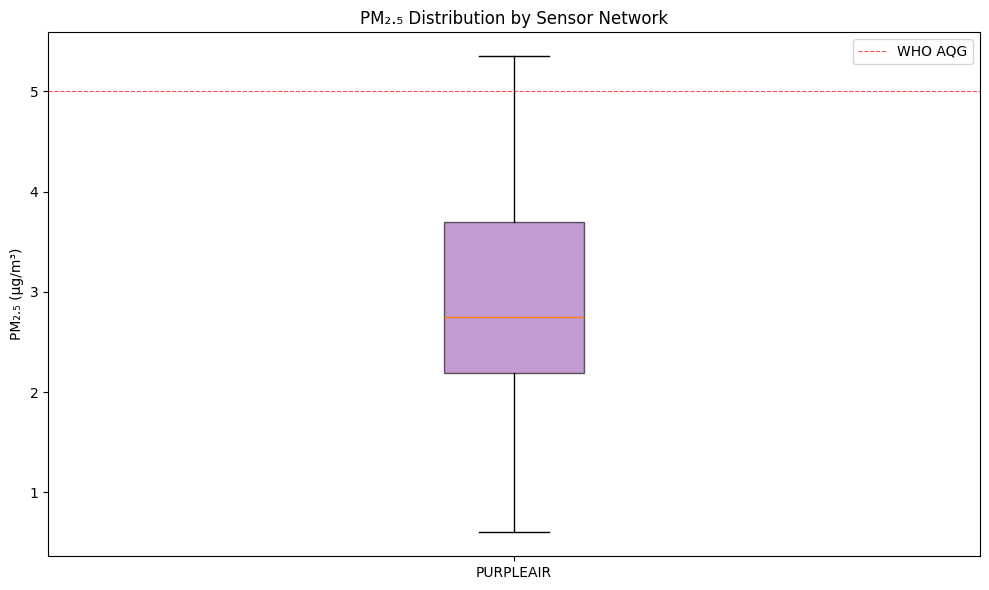

In [11]:
# Box plot comparison
fig, ax = plt.subplots(figsize=(10, 6))

networks = pm25["source_network"].unique()
data_by_network = [pm25[pm25["source_network"] == n]["value"].dropna() for n in networks]

bp = ax.boxplot(data_by_network, labels=networks, patch_artist=True)
colours = ["#9b59b6", "#2ecc71", "#3498db"]
for patch, colour in zip(bp["boxes"], colours[:len(networks)]):
    patch.set_facecolor(colour)
    patch.set_alpha(0.6)

ax.set_ylabel("PM\u2082.\u2085 (\u00b5g/m\u00b3)")
ax.set_title("PM\u2082.\u2085 Distribution by Sensor Network")
ax.axhline(5, color="red", linestyle="--", linewidth=0.8, alpha=0.7, label="WHO AQG")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Temporal Pattern Comparison

Do different sensor networks capture the same diurnal patterns?

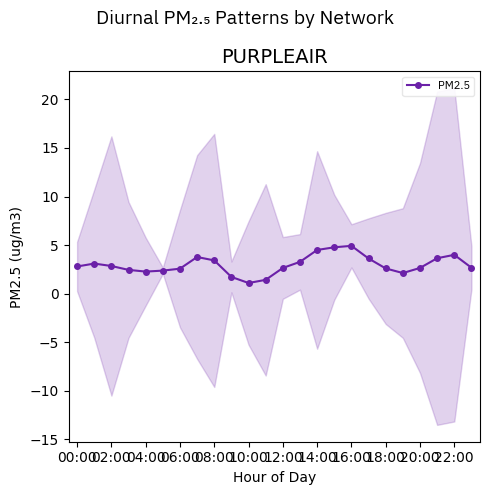

In [12]:
# Diurnal profiles by network
fig, axes = plt.subplots(1, len(networks), figsize=(5 * len(networks), 5), sharey=True)
if len(networks) == 1:
    axes = [axes]

for ax, network in zip(axes, networks):
    net_data = pm25[pm25["source_network"] == network]
    if not net_data.empty:
        viz.plot_diurnal(net_data, pollutants=["PM2.5"], ax=ax)
        ax.set_title(network)

fig.suptitle("Diurnal PM\u2082.\u2085 Patterns by Network", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Network Comparison Summary Table

In [13]:
# Build a comparison table
comparison = []

for network in networks:
    net_data = pm25[pm25["source_network"] == network]
    net_daily = daily_pm[daily_pm["source_network"] == network]
    
    comparison.append({
        "Network": network,
        "Sites": net_data["site_code"].nunique(),
        "Records": len(net_data),
        "Mean PM2.5": net_data["value"].mean(),
        "Median PM2.5": net_data["value"].median(),
        "Mean Data Capture": net_daily["data_capture"].mean() if not net_daily.empty else 0,
        "QA Flags": ", ".join(net_data["ratification"].unique()),
    })

comp_df = pd.DataFrame(comparison)
comp_df["Mean PM2.5"] = comp_df["Mean PM2.5"].round(1)
comp_df["Median PM2.5"] = comp_df["Median PM2.5"].round(1)
comp_df["Mean Data Capture"] = (comp_df["Mean Data Capture"] * 100).round(0).astype(str) + "%"

print("Network Comparison Summary")
print("=" * 80)
comp_df

Network Comparison Summary


,Network,Sites,Records,Mean PM2.5,Median PM2.5,Mean Data Capture,QA Flags
0,PURPLEAIR,1,48,3.0,2.8,67.0%,Validated


## Summary

This notebook demonstrated:

1. **Programmatic discovery** — `list_sources()` and `get_source_info()` for automated workflows
2. **Schema consistency** — three different sensor networks, one standard schema
3. **Cross-network download** — dict format for multi-source retrieval in one call
4. **Quality comparison** — ratification flags, data capture rates, measurement distributions
5. **Temporal analysis** — diurnal pattern comparison across technologies

### Key considerations for a review paper
- **Sensor technology**: PurpleAir (Plantower PMS5003), Sensor.Community (SDS011/BME280), AirQo (custom)
- **Calibration**: Each network applies different corrections
- **Data availability**: PurpleAir and Sensor.Community have global coverage; AirQo is Africa-focused
- **QA/QC**: PurpleAir provides dual-channel validation; others rely on basic range checks

### Next steps
- Find co-located sensors across networks for direct comparison
- Include a reference-grade AURN monitor as ground truth
- Analyse seasonal differences in sensor agreement
- Calculate inter-sensor correlation for co-located units